# 🤖 Challenge : Trustworthy Insights with BERT

### Objectif du projet
L'objectif est de construire un système de classification de sentiments robuste et explicable en utilisant **DistilBERT**.

### Workflows implémentés :
1. **Ingestion** : Chargement des données `tweet_eval`.
2. **Prétraitement** : Tokenisation et alignement des labels.
3. **Transfer Learning** : Fine-tuning de DistilBERT avec `Trainer` API.
4. **Évaluation & Calibration** : Mesure de la performance et analyse de la confiance (Softmax).
5. **Introspection** : Visualisation des cartes d'attention pour expliquer les prédictions.

In [1]:
!pip install -q datasets transformers[torch] evaluate accelerate matplotlib seaborn
# Force le rechargement de l'environnement pour détecter les nouveaux packages
import site
from importlib import reload
reload(site)

<module 'site' (frozen)>

## 1. Chargement et Inspection des Données

Nous utilisons le dataset `tweet_eval` (configuration sentiment) qui contient 3 classes : Négatif (0), Neutre (1), Positif (2).

In [2]:
from datasets import load_dataset
import pandas as pd

# 1. Chargement du dataset tweet_eval (configuration sentiment)
try:
    dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")
except Exception as e:
    print(f"Tentative alternative... {e}")
    dataset = load_dataset("tweet_eval", "sentiment")

# 2. Analyse de la distribution des classes
for split in dataset.keys():
    labels = dataset[split]['label']
    dist = pd.Series(labels).value_counts(normalize=True).to_dict()
    print(f"Proportion {split}: {dist}")

# 3. Extraction d'échantillons
examples = {}
for i in range(3):
    subset = dataset['test'].filter(lambda x: x['label'] == i)
    examples[i] = subset.select(range(min(2, len(subset))))['text']

print("\nVariables 'dataset' et 'examples' initialisées.")

Proportion train: {1: 0.4532061821769155, 2: 0.3912967225693303, 0: 0.15549709525375424}
Proportion test: {1: 0.4833116248778899, 0: 0.32334744382937153, 2: 0.19334093129273852}
Proportion validation: {1: 0.4345, 2: 0.4095, 0: 0.156}

Variables 'dataset' et 'examples' initialisées.


## 2. Pipeline de Tokenisation

Utilisation de `distilbert-base-uncased` pour transformer le texte en vecteurs exploitables par le modèle.

In [5]:
from transformers import AutoTokenizer

# Définition du checkpoint du modèle pré-entraîné
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

def tokenize(batch):
    # Transformation du texte brut en IDs de tokens compréhensibles par BERT
    # truncation=True : coupe les textes trop longs
    # padding='max_length' : complète les textes courts pour avoir des tenseurs uniformes
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

# Application de la tokenisation sur tout le dataset de manière optimisée (batch)
dataset_encoded = dataset.map(tokenize, batched=True)

# Conversion au format PyTorch pour l'entraînement
dataset_encoded.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

## 3. Configuration du Fine-Tuning

Nous configurons le Trainer avec l'optimisation des hyperparamètres demandée.

In [13]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate
import numpy as np
import torch
import os
import datasets

# Forcefully disable torchvision detection in datasets to prevent VideoReader ImportError
datasets.config.TORCHVISION_AVAILABLE = False
os.environ["datasets_torchvision_available"] = "False"

model_ckpt = "distilbert-base-uncased"
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy.compute(predictions=predictions, references=labels)["accuracy"],
        "f1_macro": f1.compute(predictions=predictions, references=labels, average="macro")["f1"]
    }

# Loading model with 'eager' implementation for attention visualization compatibility
model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=3,
    attn_implementation="eager"
)

training_args = TrainingArguments(
    output_dir="./distilbert-sentiment-tweet",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    learning_rate=5e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none",
    logging_steps=50
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_encoded["train"],
    eval_dataset=dataset_encoded["validation"],
    compute_metrics=compute_metrics
)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.595762,0.641696,0.719500,0.701675
2,0.476269,0.638050,0.743500,0.716185
3,0.278027,0.781761,0.734000,0.717405


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4278, training_loss=0.4693836795776567, metrics={'train_runtime': 1474.8409, 'train_samples_per_second': 92.786, 'train_steps_per_second': 2.901, 'total_flos': 4531956111832320.0, 'train_loss': 0.4693836795776567, 'epoch': 3.0})

In [14]:

# Start training
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.330059,0.707518,0.731000,0.716644
2,0.228952,0.934694,0.719500,0.691884
3,0.087552,1.275509,0.722000,0.704368


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4278, training_loss=0.21103546908103513, metrics={'train_runtime': 1474.2841, 'train_samples_per_second': 92.821, 'train_steps_per_second': 2.902, 'total_flos': 4531956111832320.0, 'train_loss': 0.21103546908103513, 'epoch': 3.0})

## 4. Évaluation et Calibration

Analyse de la confiance du modèle via l'histogramme des scores Softmax.

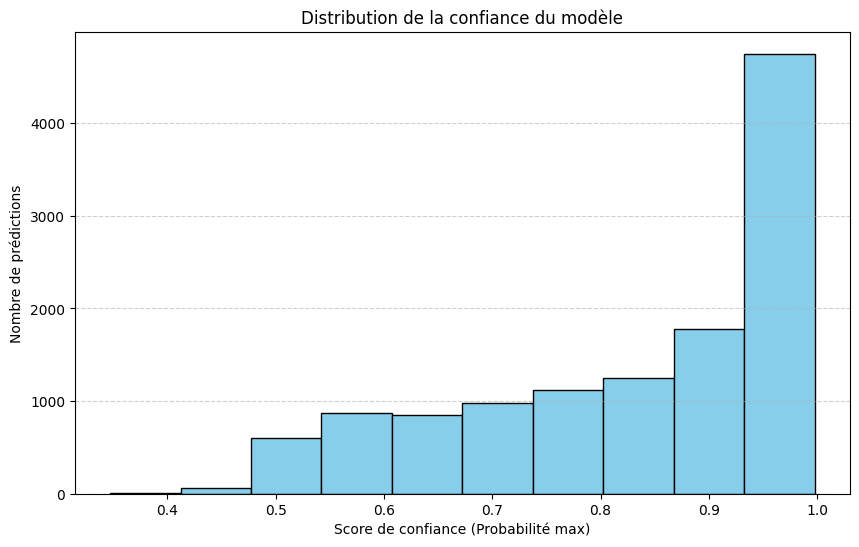

In [15]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch

# 1. Récupération des prédictions sur les données de test non vues
preds_output = trainer.predict(dataset_encoded["test"])
logits = torch.from_numpy(preds_output.predictions)

# 2. Calcul des probabilités via Softmax pour mesurer la certitude du modèle
probabilities = F.softmax(logits, dim=-1)
confidences = torch.max(probabilities, dim=-1).values.numpy()

# 3. Visualisation de la calibration
# Un modèle bien calibré ne devrait pas être systématiquement à 0.99 de confiance
plt.figure(figsize=(10, 6))
plt.hist(confidences, bins=10, color='skyblue', edgecolor='black')
plt.title("Distribution de la confiance du modèle")
plt.xlabel("Score de confiance (Probabilité max)")
plt.ylabel("Nombre de prédictions")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## 5. Inspection de l'Attention

Visualisation de ce que BERT 'regarde' pour classer un tweet.

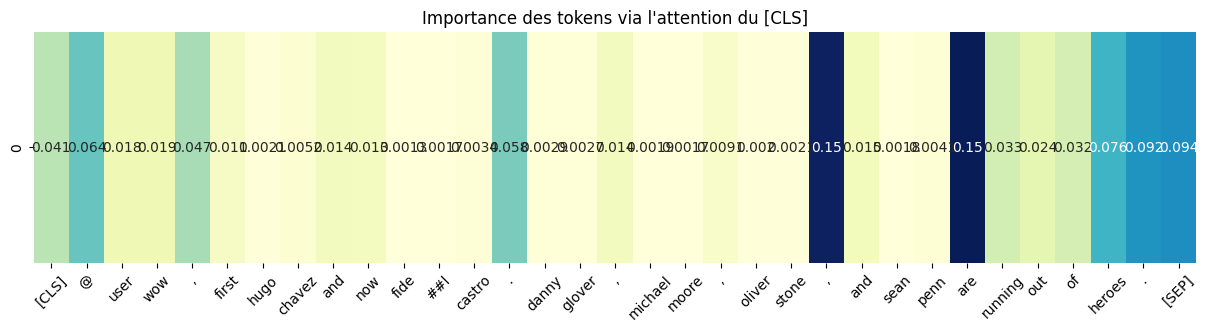

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch

def visualize_attention(text):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(model.device)

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    # Vérification si les attentions sont présentes
    if outputs.attentions is None:
        print("Erreur: Les poids d'attention n'ont pas été générés. Vérifiez que le modèle utilise attn_implementation='eager'.")
        return

    last_layer_attn = outputs.attentions[-1][0].detach().cpu()
    avg_attn = last_layer_attn.mean(dim=0)
    cls_attn = avg_attn[0, :]

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    plt.figure(figsize=(15, 3))
    sns.heatmap([cls_attn.numpy()[:len(tokens)]], xticklabels=tokens, annot=True, cbar=False, cmap="YlGnBu")
    plt.title("Importance des tokens via l'attention du [CLS]")
    plt.xticks(rotation=45)
    plt.show()

# Test sur l'exemple sauvegardé
sample_text = str(examples[0][0])
visualize_attention(sample_text)